### classifier, torch

In [1]:
%pip install --quiet torch datasets nltk tqdm matplotlib kagglehub ipywidgets numpy pandas

import numpy as np
import torch
from datasets import load_dataset
import pandas as pd


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: /Users/ant.korneev/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [4]:
with open(path + '/IMDB Dataset.csv', "r") as file:
    content = file.read()

In [5]:
df = pd.read_csv(path + '/IMDB Dataset.csv', sep=',', header=None)
print(df.to_numpy())

[['review' 'sentiment']
 ["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of

In [7]:
import nltk

tokenizer = nltk.tokenize.WordPunctTokenizer()

train = [tokenizer.tokenize(text.lower()) for text in ds[0]['text']]
val = [tokenizer.tokenize(text.lower()) for text in ds[1]['text']]


In [8]:
train_labels = [label for label in ds[0]['label']]
val_labels = [label for label in ds[1]['label']]


In [59]:
for l in val_labels:
    if l != 0:
        print(l)

In [9]:
PAD_TOKEN = '<pad>'

train_seq_len = 0
for t in train:
    if len(t) > train_seq_len:
        train_seq_len = len(t)

train = [text + [PAD_TOKEN] * (train_seq_len - len(text)) for text in train]

val_seq_len = 0
for t in val:
    if len(t) > val_seq_len:
        val_seq_len = len(t)

val = [text + [PAD_TOKEN] * (val_seq_len - len(text)) for text in val]

In [10]:
vocab_set = set()
for t in train:
    for w in t:
        vocab_set.add(w)
        
for t in val:
    for w in t:
        vocab_set.add(w)

In [11]:
vocab_i_map = {}
i_vocab_map = {}
for i, token in enumerate(vocab_set):
    vocab_i_map[token] = i
    i_vocab_map[i] = token

In [12]:
for i, text in enumerate(train):
    for j, token in enumerate(text):
        train[i][j] = vocab_i_map[token]
        
for i, text in enumerate(val):
    for j, token in enumerate(text):
        val[i][j] = vocab_i_map[token]

In [16]:
# [i_vocab_map[i] for i in val[1]]

In [17]:
vocab_size = len(vocab_set)
emb_dim = 64
inp_size = 512
hid_size = 1024

In [18]:
class Cls(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.embs = torch.nn.Embedding(vocab_size, emb_dim)
        
        self.lstm = torch.nn.LSTM(emb_dim, hid_size, 4)
        
        self.norm = torch.nn.LayerNorm(hid_size)
        self.dropout = torch.nn.Dropout(p=0.2)
        
        self.fc1 = torch.nn.Linear(hid_size, hid_size)
        self.activation1 = torch.nn.ReLU()
        
        self.fc2 = torch.nn.Linear(hid_size, 1)
        self.activation2 = torch.nn.Sigmoid()
        
        
        
    # X: [batch_size, seq_len]
    def forward(self, X):
        X = self.embs(X) # [batch_size, seq_len, emb_dim]
        
        X, (hn, cn) = self.lstm(X)
        
        X = self.norm(X)
        X = self.dropout(X)
        
        X = self.fc1(X) # [batch_size, seq_len, hid_size]
        X = self.activation1(X)
        
        X = self.fc2(X) # [batch_size, seq_len, 2]
        X = self.activation2(X)
    
        return X


In [19]:
dummy_batch = torch.tensor(train[:2])

In [20]:
model = Cls()

In [22]:
# model.forward(dummy_batch)

In [24]:
opt = torch.optim.Adam(model.parameters())

In [40]:
%pip install --upgrade tqdm

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [45]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [ ]:
batch_size = 16

train_loss = []
val_loss = []

for i in tqdm(range(0, len(train), batch_size), total=len(train) // batch_size):
    if i + batch_size > len(train):
        break
    
    batch = train[i : i + batch_size]
    batch = torch.tensor(batch)
    val_batch = val[i : i + batch_size]
    val_batch = torch.tensor(val_batch)
    
    batch_labels = train_labels[i : i + batch_size]
    batch_labels = torch.tensor(batch_labels)
    val_batch_labels = val_labels[i : i + batch_size]
    val_batch_labels = torch.tensor(val_batch_labels)
    
    preds = model.forward(batch)
    preds = preds.squeeze(dim=2)
    val_preds = model.forward(val_batch)
    val_preds = val_preds.squeeze(dim=2)
    
    batch_train_loss = torch.nn.functional.cross_entropy(preds, batch_labels)
    train_loss.append(batch_train_loss.detach().numpy())
    batch_val_loss = torch.nn.functional.cross_entropy(val_preds, val_batch_labels)
    val_loss.append(batch_val_loss.detach().numpy())
    
    batch_train_loss.backward()
    opt.step()
    opt.zero_grad()
    
    if i % 10 == 0:
        plt.clf()
        fig, ax = plt.subplots()
        ax.plot(train_loss)
        ax.plot(val_loss)
        
    
    

<Figure size 640x480 with 0 Axes>

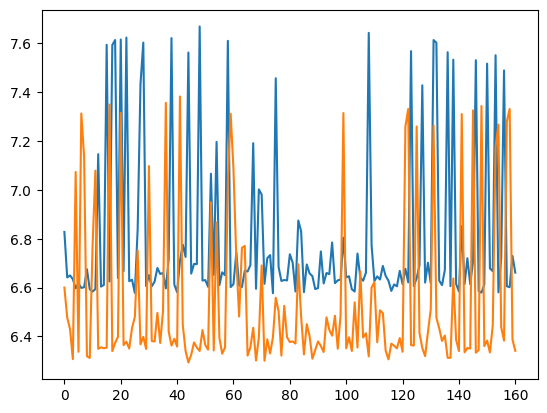

In [55]:
plt.clf()
fig, ax = plt.subplots()
ax.plot(train_loss)
ax.plot(val_loss)

In [ ]:
# TODO: predict with trained